In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator, NullFormatter
from scipy.sparse import hstack, kron, eye, csc_matrix, block_diag


def decimal_probability_tick(value, _position):
    if value <= 0:
        return ""
    if value >= 0.01:
        return f"{value:.3f}".rstrip("0").rstrip(".")
    return f"{value:.4f}".rstrip("0").rstrip(".")


def format_log_probability_axes(ax, x=True, y=True):
    """Use readable decimal ticks (0.01, 0.02, 0.05, ...) on log axes."""
    selected_axes = []
    if x:
        selected_axes.append(ax.xaxis)
    if y:
        selected_axes.append(ax.yaxis)
    for plot_axis in selected_axes:
        plot_axis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5), numticks=30))
        plot_axis.set_major_formatter(FuncFormatter(decimal_probability_tick))
        plot_axis.set_minor_locator(
            LogLocator(base=10, subs=(3, 4, 6, 7, 8, 9), numticks=100)
        )
        plot_axis.set_minor_formatter(NullFormatter())


def format_sigma_axis(ax, sigma_values):
    """Give a linear sigma axis several evenly distributed decimal labels."""
    sigma_values = np.asarray(sigma_values, dtype=float)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8, min_n_ticks=5))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}"))
    ax.set_xlim(sigma_values.min(), sigma_values.max())


def repetition_code(n):
    """
    Parity check matrix of a repetition code with length n.
    """
    row_ind, col_ind = zip(*((i, j) for i in range(n) for j in (i, (i+1)%n)))
    data = np.ones(2*n, dtype=np.uint8)
    return csc_matrix((data, (row_ind, col_ind)))


def toric_code_x_stabilisers(L):
    """
    Sparse check matrix for the X stabilisers of a toric code with
    lattice size L, constructed as the hypergraph product of
    two repetition codes.
    """
    Hr = repetition_code(L)
    H = hstack(
            [kron(Hr, eye(Hr.shape[1])), kron(eye(Hr.shape[0]), Hr.T)],
            dtype=np.uint8
        )
    H.data = H.data % 2
    H.eliminate_zeros()
    return csc_matrix(H)

In [41]:
def toric_code_x_logicals(L):
    """
    Sparse binary matrix with each row corresponding to an X logical operator
    of a toric code with lattice size L. Constructed from the
    homology groups of the repetition codes using the Kunneth
    theorem.
    """
    H1 = csc_matrix(([1], ([0],[0])), shape=(1,L), dtype=np.uint8)
    H0 = csc_matrix(np.ones((1, L), dtype=np.uint8))
    x_logicals = block_diag([kron(H1, H0), kron(H0, H1)])
    x_logicals.data = x_logicals.data % 2
    x_logicals.eliminate_zeros()
    return csc_matrix(x_logicals)

In [42]:
from pymatching import Matching

def num_decoding_failures_via_physical_frame_changes(H, logicals, error_probability, num_shots):
    matching = Matching.from_check_matrix(H, weights=np.log((1-error_probability)/error_probability))
    num_errors = 0
    for i in range(num_shots):
        noise = (np.random.random(H.shape[1]) < error_probability).astype(np.uint8)
        syndrome = H@noise % 2
        prediction = matching.decode(syndrome)
        predicted_logicals_flipped = logicals@prediction % 2
        actual_logicals_flipped = logicals@noise % 2
        if not np.array_equal(predicted_logicals_flipped, actual_logicals_flipped):
            num_errors += 1
    return num_errors

In [43]:
def num_decoding_failures(H, logicals, error_probability, num_shots):
    matching = Matching.from_check_matrix(H, weights=np.log((1-error_probability)/error_probability), faults_matrix=logicals)
    num_errors = 0
    for i in range(num_shots):
        noise = (np.random.random(H.shape[1]) < error_probability).astype(np.uint8)
        syndrome = H@noise % 2
        predicted_logicals_flipped = matching.decode(syndrome)
        actual_logicals_flipped = logicals@noise % 2
        if not np.array_equal(predicted_logicals_flipped, actual_logicals_flipped):
            num_errors += 1
    return num_errors

def num_decoding_failures_vectorised(H, logicals, error_probability, num_shots):
    matching = Matching.from_check_matrix(H, weights=np.log((1-error_probability)/error_probability), faults_matrix=logicals)
    noise = (np.random.random((num_shots, H.shape[1])) < error_probability).astype(np.uint8)
    shots = (noise @ H.T) % 2
    actual_observables = (noise @ logicals.T) % 2
    predicted_observables = matching.decode_batch(shots)
    num_errors = np.sum(np.any(predicted_observables != actual_observables, axis=1))
    return num_errors

Simulating L=4...
Simulating L=8...
Simulating L=12...
CPU times: total: 2.5 s
Wall time: 2.64 s


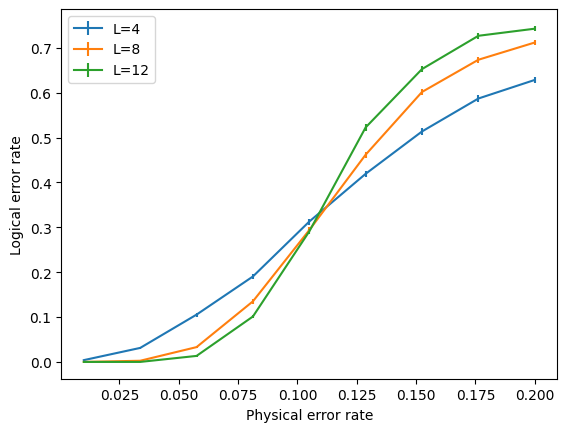

In [44]:
%%time

num_shots = 5000
Ls = range(4,14,4)
ps = np.linspace(0.01, 0.2, 9)
np.random.seed(2)
log_errors_all_L = []
for L in Ls:
    print("Simulating L={}...".format(L))
    Hx = toric_code_x_stabilisers(L)
    logX = toric_code_x_logicals(L)
    log_errors = []
    for error_probability in ps:
        num_errors = num_decoding_failures_vectorised(Hx, logX, error_probability, num_shots)
        log_errors.append(num_errors/num_shots)
    log_errors_all_L.append(np.array(log_errors))

%matplotlib inline

plt.figure()
for L, logical_errors in zip(Ls, log_errors_all_L):
    std_err = (logical_errors*(1-logical_errors)/num_shots)**0.5
    plt.errorbar(ps, logical_errors, yerr=std_err, label="L={}".format(L))
plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.legend(loc=0);

In [45]:
def num_decoding_failures_noisy_syndromes(H, logicals, p, q, num_shots, repetitions):
    matching = Matching(H, weights=np.log((1-p)/p),
                repetitions=repetitions, timelike_weights=np.log((1-q)/q), faults_matrix=logicals)
    num_stabilisers, num_qubits = H.shape
    num_errors = 0
    for i in range(num_shots):
        noise_new = (np.random.rand(num_qubits, repetitions) < p).astype(np.uint8)
        noise_cumulative = (np.cumsum(noise_new, 1) % 2).astype(np.uint8)
        noise_total = noise_cumulative[:,-1]
        syndrome = H@noise_cumulative % 2
        syndrome_error = (np.random.rand(num_stabilisers, repetitions) < q).astype(np.uint8)
        syndrome_error[:,-1] = 0 # Perfect measurements in last round to ensure even parity
        noisy_syndrome = (syndrome + syndrome_error) % 2
        # Convert to difference syndrome
        noisy_syndrome[:,1:] = (noisy_syndrome[:,1:] - noisy_syndrome[:,0:-1]) % 2
        predicted_logicals_flipped = matching.decode(noisy_syndrome)
        actual_logicals_flipped = noise_total@logicals.T % 2
        if not np.array_equal(predicted_logicals_flipped, actual_logicals_flipped):
            num_errors += 1
    return num_errors

Simulating L=8...
Simulating L=10...
Simulating L=12...
CPU times: total: 21.4 s
Wall time: 22.3 s


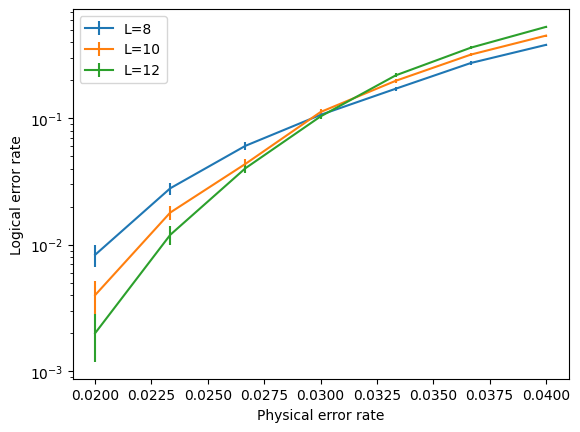

In [46]:
%%time

num_shots = 3000
Ls = range(8,13,2)
ps = np.linspace(0.02, 0.04, 7)
log_errors_all_L = []
for L in Ls:
    print("Simulating L={}...".format(L))
    Hx = toric_code_x_stabilisers(L)
    logX = toric_code_x_logicals(L)
    log_errors = []
    for p in ps:
        num_errors = num_decoding_failures_noisy_syndromes(Hx, logX, p, p, num_shots, L)
        log_errors.append(num_errors/num_shots)
    log_errors_all_L.append(np.array(log_errors))

%matplotlib inline

plt.figure()
for L, logical_errors in zip(Ls, log_errors_all_L):
    std_err = (logical_errors*(1-logical_errors)/num_shots)**0.5
    plt.errorbar(ps, logical_errors, yerr=std_err, label="L={}".format(L))
plt.yscale("log")
plt.xlabel("Physical error rate")
plt.ylabel("Logical error rate")
plt.legend(loc=0)

## GKP displacement noise and correction over time

This keeps the tutorial's spacetime toric-code decoder, but replaces each Bernoulli data or measurement fault with a Gaussian GKP displacement. Nearest-lattice-point correction reduces the displacement modulo $\sqrt{\pi}$; an odd number of lattice shifts is the binary Pauli fault passed to the outer toric code. This first version is a hard-decision baseline, so the matching weights use the unconditional physical GKP error probability.

In [47]:
from scipy.special import ndtr

sqrt_pi = np.sqrt(np.pi)

def gkp_correct_displacements(displacements):
    """Apply ideal square-GKP correction and return residuals and Pauli faults."""
    displacements = np.asarray(displacements, dtype=float)
    residuals = (displacements + sqrt_pi / 2) % sqrt_pi - sqrt_pi / 2
    lattice_shifts = np.rint((displacements - residuals) / sqrt_pi).astype(np.int64)
    faults = (lattice_shifts % 2).astype(np.uint8)
    return residuals, faults

def gkp_physical_error_rate(sigma, number_of_intervals=100):
    """Unconditional probability that ideal GKP correction gives a Pauli fault."""
    if sigma <= 0:
        raise ValueError("sigma must be positive")
    probability = 0.0
    for m in range(number_of_intervals):
        lower = (2 * m + 0.5) * sqrt_pi / sigma
        upper = (2 * m + 1.5) * sqrt_pi / sigma
        probability += 2 * (ndtr(-lower) - ndtr(-upper))
    return probability

def num_decoding_failures_gkp_noisy_syndromes(
    H, logicals, sigma, num_shots, repetitions
):
    # Data and measurement GKP corrections have the same sigma here.
    p_gkp = gkp_physical_error_rate(sigma)
    weight = np.log((1.0 - p_gkp) / p_gkp)
    matching = Matching(
        H,
        weights=weight,
        repetitions=repetitions,
        timelike_weights=weight,
        faults_matrix=logicals,
    )

    num_stabilisers, num_qubits = H.shape
    num_errors = 0

    for _ in range(num_shots):
        # A fresh Gaussian displacement acts on every data qubit in every round.
        data_displacements = np.random.normal(0.0, sigma, (num_qubits, repetitions))
        _, data_faults = gkp_correct_displacements(data_displacements)
        cumulative_faults = np.cumsum(data_faults, axis=1).astype(np.uint8) % 2
        final_data_fault = cumulative_faults[:, -1]

        ideal_syndrome = (H @ cumulative_faults) % 2

        # GKP correction of each analog stabiliser readout produces measurement faults.
        measurement_displacements = np.random.normal(
            0.0, sigma, (num_stabilisers, repetitions)
        )
        _, measurement_faults = gkp_correct_displacements(measurement_displacements)
        measurement_faults[:, -1] = 0  # tutorial convention: final round is perfect

        noisy_syndrome = (ideal_syndrome + measurement_faults) % 2
        noisy_syndrome[:, 1:] = (
            noisy_syndrome[:, 1:] - noisy_syndrome[:, :-1]
        ) % 2

        predicted_logicals = matching.decode(noisy_syndrome)
        actual_logicals = final_data_fault @ logicals.T % 2
        if not np.array_equal(predicted_logicals, actual_logicals):
            num_errors += 1

    return num_errors

Simulating GKP toric code L=8...
Simulating GKP toric code L=10...
Simulating GKP toric code L=12...


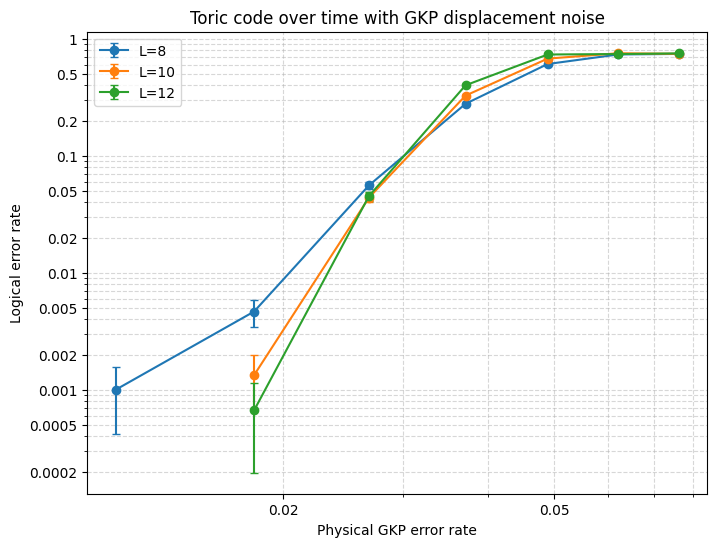

In [48]:
num_shots = 3000
Ls = range(8, 13, 2)
sigma_values = np.linspace(0.30, 0.50, 9)
logical_errors_all_L = []

for L in Ls:
    print(f"Simulating GKP toric code L={L}...")
    Hx = toric_code_x_stabilisers(L)
    logX = toric_code_x_logicals(L)
    logical_errors = []
    for sigma in sigma_values:
        failures = num_decoding_failures_gkp_noisy_syndromes(
            Hx, logX, sigma, num_shots, repetitions=L
        )
        logical_errors.append(failures / num_shots)
    logical_errors_all_L.append(np.asarray(logical_errors))

physical_error_rates = np.array([gkp_physical_error_rate(s) for s in sigma_values])
plt.figure(figsize=(8, 6))
for L, logical_errors in zip(Ls, logical_errors_all_L):
    std_err = np.sqrt(logical_errors * (1 - logical_errors) / num_shots)
    visible = logical_errors > 0
    plt.errorbar(
        physical_error_rates[visible], logical_errors[visible],
        yerr=std_err[visible], marker="o", capsize=3, label=f"L={L}"
    )
plt.xscale("log")
plt.yscale("log")
format_log_probability_axes(plt.gca())
plt.xlabel("Physical GKP error rate")
plt.ylabel("Logical error rate")
plt.title("Toric code over time with GKP displacement noise")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

## Soft-information GKP spacetime decoding

The hard decoder above assigns the same reliability to every fault location. Here each corrected GKP residual $s$ supplies its own log-likelihood weight, $w(s)=[(\sqrt{\pi}-|s|)^2-s^2]/(2\sigma^2)$. Residuals near zero get large weights (reliable), while residuals near a decision boundary get weights near zero (uncertain). Because these weights differ at every location and round, this cell constructs the explicit three-dimensional check matrix used by the cluster implementation.

In [49]:
from scipy.sparse import vstack

def gkp_residual_fault_and_weight(displacements, sigma):
    """Return GKP residuals, hard faults, and residual-dependent weights."""
    residuals, faults = gkp_correct_displacements(displacements)
    weights = (
        (sqrt_pi - np.abs(residuals)) ** 2 - residuals ** 2
    ) / (2 * sigma**2)
    return residuals, faults, weights

def toric_spacetime_check_matrix(H, repetitions):
    """Explicit detector matrix: data faults followed by measurement faults."""
    num_stabilisers, num_qubits = H.shape
    zero_space_row = csc_matrix(
        (num_stabilisers, repetitions * num_qubits), dtype=np.uint8
    )
    H_space = vstack([
        kron(eye(repetitions, dtype=np.uint8), H),
        zero_space_row,
    ])

    identity = eye(num_stabilisers, dtype=np.uint8)
    zero = csc_matrix((num_stabilisers, num_stabilisers), dtype=np.uint8)
    time_rows = []
    for detector_round in range(repetitions + 1):
        time_rows.append(hstack([
            identity if detector_round in (fault_round, fault_round + 1) else zero
            for fault_round in range(repetitions)
        ]))
    H_time = vstack(time_rows)

    H_spacetime = hstack([H_space, H_time]).tocsc()
    H_spacetime.data %= 2
    H_spacetime.eliminate_zeros()
    return H_spacetime

def num_decoding_failures_gkp_soft(
    H, logicals, sigma, num_shots, repetitions
):
    num_stabilisers, num_qubits = H.shape
    H_spacetime = toric_spacetime_check_matrix(H, repetitions)
    num_errors = 0

    for _ in range(num_shots):
        data_faults_by_round = []
        data_weights_by_round = []
        cumulative_data_fault = np.zeros(num_qubits, dtype=np.uint8)
        ideal_syndromes = []

        for _round in range(repetitions):
            displacement = np.random.normal(0.0, sigma, num_qubits)
            _, faults, weights = gkp_residual_fault_and_weight(displacement, sigma)
            data_faults_by_round.append(faults)
            data_weights_by_round.append(weights)
            cumulative_data_fault = (cumulative_data_fault + faults) % 2
            ideal_syndromes.append((H @ cumulative_data_fault) % 2)

        noisy_syndromes = []
        measurement_weights_by_round = []
        for round_index in range(repetitions):
            displacement = np.random.normal(0.0, sigma, num_stabilisers)
            _, measurement_fault, weights = gkp_residual_fault_and_weight(
                displacement, sigma
            )
            noisy_syndromes.append(
                (ideal_syndromes[round_index] + measurement_fault) % 2
            )
            measurement_weights_by_round.append(weights)

        # Detector differences, followed by a perfect final measurement.
        detectors = []
        previous_syndrome = np.zeros(num_stabilisers, dtype=np.uint8)
        for round_index in range(repetitions + 1):
            current_syndrome = (
                noisy_syndromes[round_index]
                if round_index < repetitions
                else (H @ cumulative_data_fault) % 2
            )
            detectors.append((current_syndrome + previous_syndrome) % 2)
            previous_syndrome = current_syndrome

        detector_vector = np.concatenate(detectors)
        weight_vector = np.concatenate(
            data_weights_by_round + measurement_weights_by_round
        )
        # PyMatching 2.x assigns weights when the graph is constructed;
        # decode() does not accept per-shot edge weights.
        shot_matching = Matching.from_check_matrix(
            H_spacetime, weights=weight_vector
        )
        correction = shot_matching.decode(detector_vector)

        cumulative_correction = np.zeros(num_qubits, dtype=np.uint8)
        for round_index in range(repetitions):
            start = round_index * num_qubits
            cumulative_correction ^= correction[start:start + num_qubits].astype(np.uint8)

        residual_fault = cumulative_data_fault ^ cumulative_correction
        if np.any((logicals @ residual_fault) % 2):
            num_errors += 1

    return num_errors

Simulating soft GKP toric code L=4...
Simulating soft GKP toric code L=6...
Simulating soft GKP toric code L=8...


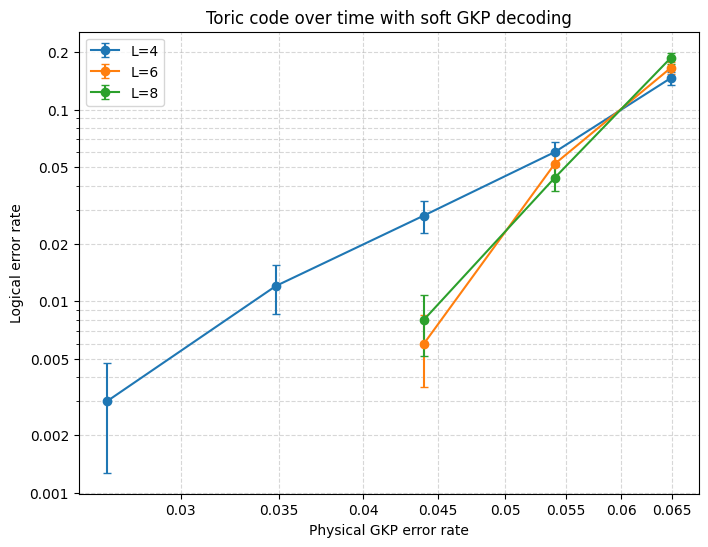

In [50]:
# Start with small values: soft decoding constructs new weights for every shot.
num_shots_soft = 1000
Ls_soft = [4, 6, 8]
sigma_values_soft = np.linspace(0.32, 0.48, 9)
soft_logical_errors_all_L = []

for L in Ls_soft:
    print(f"Simulating soft GKP toric code L={L}...")
    Hx = toric_code_x_stabilisers(L)
    logX = toric_code_x_logicals(L)
    rates = []
    for sigma in sigma_values_soft:
        failures = num_decoding_failures_gkp_soft(
            Hx, logX, sigma, num_shots_soft, repetitions=L
        )
        rates.append(failures / num_shots_soft)
    soft_logical_errors_all_L.append(np.asarray(rates))

soft_physical_rates = np.array([
    gkp_physical_error_rate(sigma) for sigma in sigma_values_soft
])
plt.figure(figsize=(8, 6))
for L, logical_errors in zip(Ls_soft, soft_logical_errors_all_L):
    std_err = np.sqrt(logical_errors * (1 - logical_errors) / num_shots_soft)
    visible = logical_errors > 0
    plt.errorbar(
        soft_physical_rates[visible], logical_errors[visible],
        yerr=std_err[visible], marker="o", capsize=3, label=f"L={L}"
    )
plt.xscale("log")
plt.yscale("log")
format_log_probability_axes(plt.gca())
plt.xlabel("Physical GKP error rate")
plt.ylabel("Logical error rate")
plt.title("Toric code over time with soft GKP decoding")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

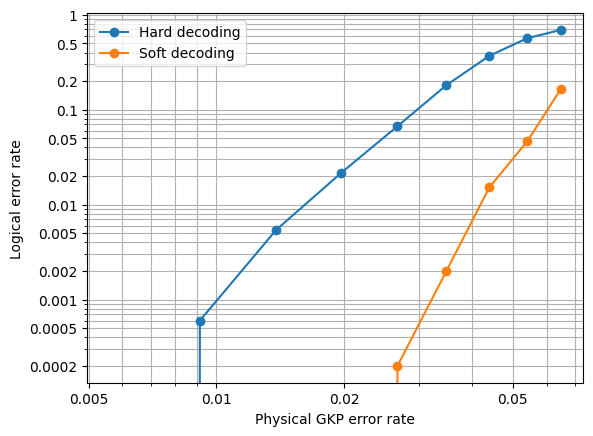

In [51]:
L = 6
num_shots = 5000
sigma_values = np.linspace(0.32, 0.48, 9)

hard_rates = []
soft_rates = []

Hx = toric_code_x_stabilisers(L)
logX = toric_code_x_logicals(L)

for sigma in sigma_values:
    hard_failures = num_decoding_failures_gkp_noisy_syndromes(
        Hx, logX, sigma, num_shots, repetitions=L
    )
    soft_failures = num_decoding_failures_gkp_soft(
        Hx, logX, sigma, num_shots, repetitions=L
    )

    hard_rates.append(hard_failures / num_shots)
    soft_rates.append(soft_failures / num_shots)

physical_rates = [
    gkp_physical_error_rate(sigma) for sigma in sigma_values
]

plt.plot(physical_rates, hard_rates, "o-", label="Hard decoding")
plt.plot(physical_rates, soft_rates, "o-", label="Soft decoding")
plt.xscale("log")
plt.yscale("log")
format_log_probability_axes(plt.gca())
plt.xlabel("Physical GKP error rate")
plt.ylabel("Logical error rate")
plt.legend()
plt.grid(True, which="both")
plt.show()

## Ordinary, hard-GKP, and soft-GKP toric comparison

These three panels use the same distance, number of rounds, sigma values, and number of shots. The ordinary toric simulation uses Bernoulli rates $p=q=p_{\mathrm{GKP}}(\sigma)$, making its physical fault frequency comparable to the two GKP simulations.

L=6, sigma=0.320, p_GKP=0.0056149
L=6, sigma=0.340, p_GKP=0.009146
L=6, sigma=0.360, p_GKP=0.013826
L=6, sigma=0.380, p_GKP=0.019691
L=6, sigma=0.400, p_GKP=0.026721
L=6, sigma=0.420, p_GKP=0.034853
L=6, sigma=0.440, p_GKP=0.043994
L=6, sigma=0.460, p_GKP=0.054032
L=6, sigma=0.480, p_GKP=0.064848


C:\Users\laram\AppData\Local\Temp\ipykernel_13136\2231306354.py:65: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1)


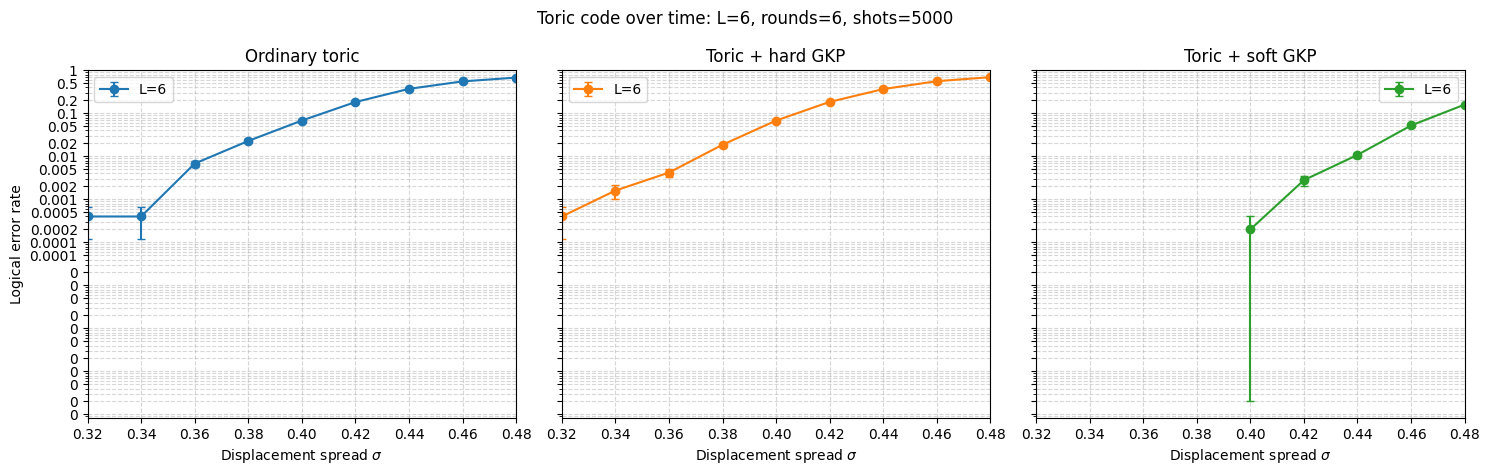

In [53]:
panel_L = 6
panel_shots = 5000
panel_sigmas = np.linspace(0.32, 0.48, 9)

Hx = toric_code_x_stabilisers(panel_L)
logX = toric_code_x_logicals(panel_L)
ordinary_rates = []
hard_gkp_rates = []
soft_gkp_rates = []

for sigma in panel_sigmas:
    physical_probability = gkp_physical_error_rate(sigma)
    print(f"L={panel_L}, sigma={sigma:.3f}, p_GKP={physical_probability:.5g}")

    ordinary_failures = num_decoding_failures_noisy_syndromes(
        Hx, logX, physical_probability, physical_probability,
        panel_shots, repetitions=panel_L
    )
    hard_failures = num_decoding_failures_gkp_noisy_syndromes(
        Hx, logX, sigma, panel_shots, repetitions=panel_L
    )
    soft_failures = num_decoding_failures_gkp_soft(
        Hx, logX, sigma, panel_shots, repetitions=panel_L
    )

    ordinary_rates.append(ordinary_failures / panel_shots)
    hard_gkp_rates.append(hard_failures / panel_shots)
    soft_gkp_rates.append(soft_failures / panel_shots)

panel_rate_sets = [
    np.asarray(ordinary_rates),
    np.asarray(hard_gkp_rates),
    np.asarray(soft_gkp_rates),
]
panel_titles = [
    "Ordinary toric",
    "Toric + hard GKP",
    "Toric + soft GKP",
]
panel_colours = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, rates, title, colour in zip(
    axes, panel_rate_sets, panel_titles, panel_colours
):
    errors = np.sqrt(rates * (1 - rates) / panel_shots)
    visible = rates > 0
    ax.errorbar(
        panel_sigmas[visible], rates[visible], yerr=errors[visible],
        marker="o", capsize=3, color=colour, label=f"L={panel_L}"
    )
    ax.set_yscale("log")
    format_log_probability_axes(ax, x=False, y=True)
    format_sigma_axis(ax, panel_sigmas)
    ax.set_title(title)
    ax.set_xlabel(r"Displacement spread $\sigma$")
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()

axes[0].set_ylabel("Logical error rate")
fig.suptitle(
    f"Toric code over time: L={panel_L}, rounds={panel_L}, shots={panel_shots}"
)
fig.tight_layout()
plt.ylim(0, 1)
plt.show()